In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv('combined_datasetflow2_cleaned_model.csv')
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = pd.read_csv("combined_datasetflow2_cleaned_model.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (28132, 89)
   dst_port protocol  duration  total_bytes  total_packets  fwd_pkts  fwd_bytes  fwd_pkt_len_mean  fwd_pkt_len_std  fwd_pkt_len_min  fwd_pkt_len_max  fwd_iat_mean  fwd_iat_std  fwd_iat_min  \
0       443      TCP  0.414215         4391             18         9       1069          118.7778          96.0599             54.0            331.0      0.051777     0.060601     0.000052   
1       443      TCP  0.058407         4369             17         9       1101          122.3333          98.8849             54.0            331.0      0.007301     0.008833     0.000067   
2       443      TCP  0.038559         4261             15         8       1047          130.8750         101.7048             54.0            331.0      0.005508     0.008076     0.000184   
3       443      TCP  0.037885         4261             15         8       1047          130.8750         101.7048             54.0            331.0      0.005412     0.008064     0.000093   
4       443      TCP 

In [33]:
# Cell 2: Keep only your selected features
features = [
    "protocol",
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_fingerprint",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "ja3_fingerprint",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts",
    "label"
]

missing_cols = [c for c in features if c not in df.columns]
print("Missing columns:", missing_cols)

df = df[features].copy()
print("New shape:", df.shape)
print(df.head())

Missing columns: []
New shape: (28132, 28)
  protocol  duration  total_bytes  total_packets  bytes_per_second  packets_per_second  pkt_len_mean  pkt_len_std  iat_mean   iat_std  burstiness  burst_count  is_complete_handshake  has_tls  \
0      TCP  0.414215         4391             18        10600.7750             43.4557      243.9444     361.0636  0.024366  0.048840      2.0045            1                      1        1   
1      TCP  0.058407         4369             17        74802.6778            291.0610      257.0000     368.1982  0.003650  0.007186      1.9686            1                      1        1   
2      TCP  0.038559         4261             15       110505.9779            389.0142      284.0667     383.9515  0.002754  0.006277      2.2790            1                      1        1   
3      TCP  0.037885         4261             15       112471.9546            395.9351      284.0667     383.9515  0.002706  0.006265      2.3151            1                      1

In [34]:
# Cell 3: Basic cleaning checks
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After drop_duplicates:", df.duplicated().sum())

print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("Label counts:")
print(df["label"].value_counts())
print("Label proportions:")
print(df["label"].value_counts(normalize=True).round(4))

Duplicate rows: 7
After drop_duplicates: 0
Missing values:
protocol                 0
duration                 0
total_bytes              0
total_packets            0
bytes_per_second         0
packets_per_second       0
pkt_len_mean             0
pkt_len_std              0
iat_mean                 0
iat_std                  0
burstiness               0
burst_count              0
is_complete_handshake    0
has_tls                  0
tls_cipher_count         0
tls_ext_count            0
ja4_fingerprint          0
ja4_tls_ver_num          0
ja4_cipher_count         0
ja4_ext_count            0
ja4_sni_present          0
ja4_has_alpn             0
ja3_fingerprint          0
dns_query_count          0
dns_unique_queries       0
http_request_count       0
http_unique_hosts        0
label                    0
dtype: int64
Label counts:
label
emotet           13972
trickbot         10904
minor_project     3190
dreambot            59
Name: count, dtype: int64
Label proportions:
label
emotet   

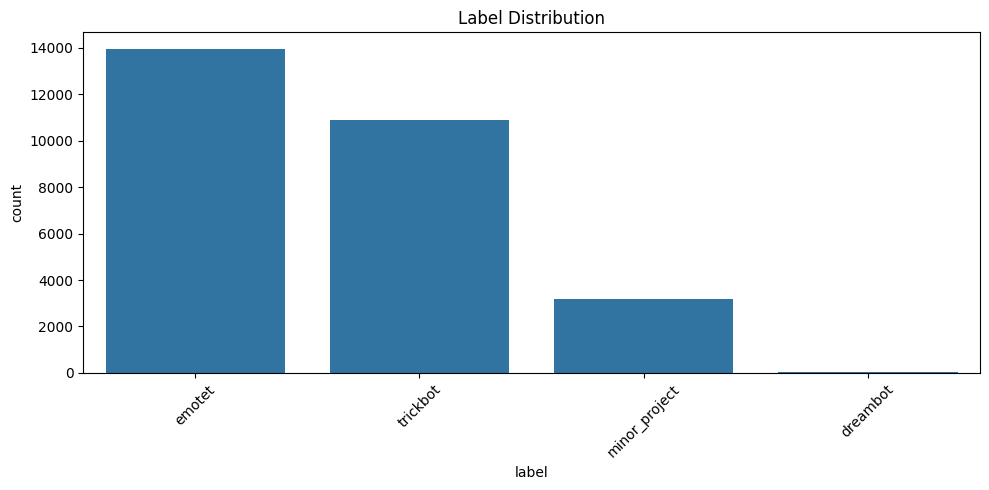

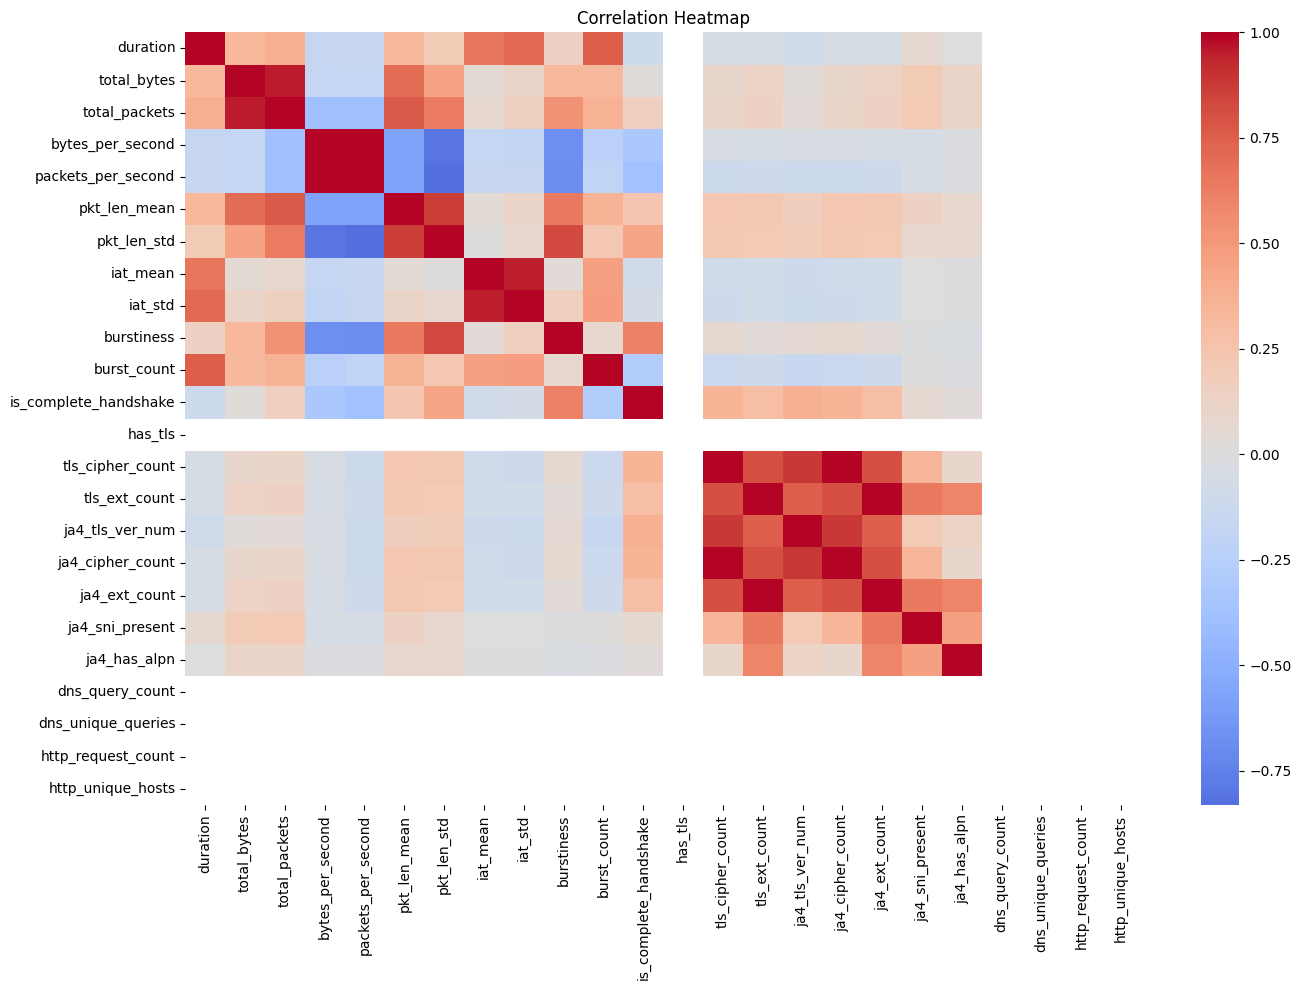

In [35]:
# Cell 4: EDA plots
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Label Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

top_missing = df.isnull().sum().sort_values(ascending=False)
top_missing = top_missing[top_missing > 0]

if len(top_missing) > 0:
    plt.figure(figsize=(12, 5))
    top_missing.head(20).plot(kind="bar")
    plt.title("Top Missing Columns")
    plt.ylabel("Missing Count")
    plt.tight_layout()
    plt.show()

In [36]:
# Cell 6: Preprocessing for CNN
X = df.drop(columns=["label"]).copy()
y = df["label"].copy()

# Fill missing values
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].astype("string").fillna("unknown")
    else:
        X[col] = X[col].fillna(X[col].median())

# Optional flags for sparse fingerprint fields
if "ja4_fingerprint" in X.columns:
    X["has_ja4"] = (X["ja4_fingerprint"] != "unknown").astype(int)
if "ja3_fingerprint" in X.columns:
    X["has_ja3"] = (X["ja3_fingerprint"] != "unknown").astype(int)

# Encode categorical columns
cat_cols = ["protocol", "ja4_fingerprint", "ja3_fingerprint"]
for col in cat_cols:
    if col in X.columns:
        X[col] = pd.factorize(X[col])[0]

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

print("Classes:", list(label_encoder.classes_))
print("X shape:", X.shape)
print("y shape:", y_categorical.shape)

NameError: name 'tf' is not defined